# Gene Expression Cancer RNA-Seq — классификация типа рака по генетическим данным

**Задача:** по уровню экспрессии 20 531 гена определить один из пяти типов рака

**Данные:** [Gene expression cancer RNA-Seq](https://archive.ics.uci.edu/dataset/401/gene+expression+cancer+rna+seq)
(UCI ML Repository, часть проекта TCGA Pan-Cancer)

**План:**
1. Загрузка данных
2. EDA
3. Препроцессинг — train/test split, масштабирование
4. PCA
5. SVM — с PCA и без, сравнение
6. K-means
7. Выводы


## 1. Импорты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    adjusted_rand_score, silhouette_score,
)

In [2]:

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 20

## 2. Загрузка данных

In [3]:
X_raw = pd.read_csv("/kaggle/input/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016/data.csv", index_col=0)
y_raw = pd.read_csv("/kaggle/input/datasets/waalbannyantudre/gene-expression-cancer-rna-seq-donated-on-682016/labels.csv", index_col=0)["Class"]

print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)

X_raw: (801, 20531)
y_raw: (801,)


In [4]:
X_raw.head()

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,gene_10,gene_11,gene_12,gene_13,gene_14,gene_15,gene_16,gene_17,gene_18,gene_19,gene_20,gene_21,gene_22,gene_23,gene_24,...,gene_20506,gene_20507,gene_20508,gene_20509,gene_20510,gene_20511,gene_20512,gene_20513,gene_20514,gene_20515,gene_20516,gene_20517,gene_20518,gene_20519,gene_20520,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,0.591871,1.334282,2.015391,0.591871,0.0,0.0,0.0,0.0,0.591871,5.619994,1.334282,0.000000,9.796088,0.0,0.000000,...,7.846957,2.824951,6.239396,0.000000,8.469593,0.0,6.535978,6.968701,7.128881,7.175175,9.249369,7.025970,8.045563,7.475709,7.205236,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,0.000000,0.587845,2.466601,1.004394,0.0,0.0,0.0,0.0,0.000000,11.055208,3.562621,0.000000,10.070470,0.0,0.000000,...,7.161001,0.000000,4.708877,0.811142,8.451689,0.0,7.242336,8.046284,6.047558,8.572901,7.549030,7.019935,9.458940,9.190867,10.639259,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,0.000000,0.452595,1.981122,1.074163,0.0,0.0,0.0,0.0,1.683023,8.210248,4.195285,3.660427,8.970920,0.0,0.000000,...,7.527555,0.000000,4.997902,0.796598,7.761132,0.0,6.820460,8.048983,6.661493,7.716332,6.745802,7.524667,8.602350,9.036654,10.336027,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0,7.843375,0.434882,0.0,0.0,0.000000,0.434882,2.874246,0.000000,0.0,0.0,0.0,0.0,1.267356,8.306317,3.573556,0.000000,8.524616,0.0,0.000000,...,8.319085,1.791814,5.661134,1.464093,8.625727,0.0,7.420095,7.784746,7.613915,8.963286,7.744699,7.924997,8.981473,8.665592,9.194823,6.076566,8.792959,10.141520,8.942805,9.601208,11.392682,9.694814,9.684365,3.292001,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0,6.566967,0.360982,0.0,0.0,0.000000,1.275841,2.141204,0.000000,0.0,0.0,0.0,0.0,0.889707,10.149150,2.967630,0.000000,8.047238,0.0,1.435949,...,8.227717,0.360982,6.227104,0.649386,8.151879,0.0,6.558289,8.673708,6.505099,8.948989,7.010366,7.364056,8.950646,8.233366,9.298775,5.996032,8.891425,10.373790,7.181162,9.846910,11.922439,9.217749,9.461191,5.110372,0.0


## 3. EDA

### 3.1 Общий обзор и дисбаланс классов

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

Class
BRCA    37.5 %
KIRC    18.2 %
LUAD    17.6 %
PRAD    17.0 %
COAD     9.7 %
Name: proportion, dtype: object


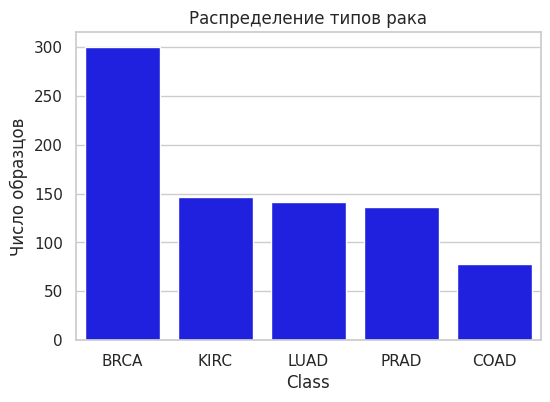

In [8]:
class_counts = y_raw.value_counts()
print(class_counts)
print()
print((y_raw.value_counts(normalize=True) * 100).round(1).astype(str) + " %")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, color="blue")
ax.set_ylabel("Число образцов")
ax.set_title("Распределение типов рака")
plt.show()


Класс `BRCA` больше остальных
Дисбаланс не такой резкий, но все равно стоит использовать **macro F1** (среднее по классам без взвешивания на размер) в дополнение к accuracy — иначе качество на маленьких классах может быть незаметно на общем фоне

In [9]:
n_samples, n_features = X_raw.shape
print(f"Объектов (пациентов): {n_samples}")
print(f"Признаков (генов): {n_features}")
print(f"Соотношение признаков к объектам: {n_features / n_samples:.1f}x")

Объектов (пациентов): 801
Признаков (генов): 20531
Соотношение признаков к объектам: 25.6x


Признаков в **25 раз больше**, чем объектов.
в таком случае логично использовать PCA, чтобы сократить число измерений, оставив только нужные признаки

### 3.3 Пропуски

In [10]:
print("Пропусков в данных:", X_raw.isnull().sum().sum())

Пропусков в данных: 0


### 3.4 Избыточность признаков, корреляция между случайными генами

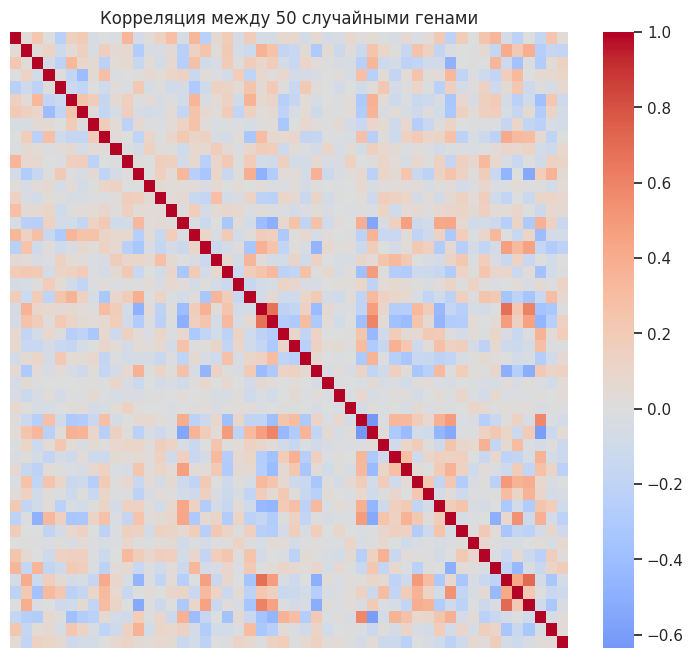

Средняя абсолютная корреляция между 50 генами: 0.125


In [12]:
np.random.seed(RANDOM_STATE)
sample_50_genes = np.random.choice(X_raw.columns, size=50, replace=False)
corr_matrix = X_raw[sample_50_genes].corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax,
            xticklabels=False, yticklabels=False)
ax.set_title("Корреляция между 50 случайными генами")
plt.show()

print("Средняя абсолютная корреляция между 50 генами:",
      corr_matrix.values[np.triu_indices(50, k=1)].__abs__().mean().round(3))

Даже среди случайно выбранных 50 генов из 20531 заметны блоки заметной корреляции, поэтому гены не работают независимо друг от друга, многие регулируются согласованно

**Вывод по EDA и план.** 

Классы количественно разбалансированы => можно считать macro F1 в дополнение к accuracy. Признаков в 25 раз больше, чем объектов, с корреляцией между признаки => будет использован PCA. 
Пропусков нет.
Обязательно нужно масштабировать признаки (`StandardScaler`) перед PCA и SVM, потому что оба метода чувствительны к масштабу: PCA ищет направления максимальной дисперсии, и без масштабирования гены с изначально большим разбросом значений доминировали бы только за счет единиц измерения, а не реальной биологической значимости, а SVM измеряет расстояния между точками, которые точно так же исказятся при разных масштабах признаков

## 4. Препроцессинг

### 4.1 Train/test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "test:", X_test.shape)
print(y_train.value_counts(normalize=True).round(3))

train: (640, 20531) test: (161, 20531)
Class
BRCA    0.375
KIRC    0.181
LUAD    0.177
PRAD    0.170
COAD    0.097
Name: proportion, dtype: float64


### 4.2 Масштабирование

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. PCA

Обучение PCA **только на train**

### 5.1 Сколько компонент нужно

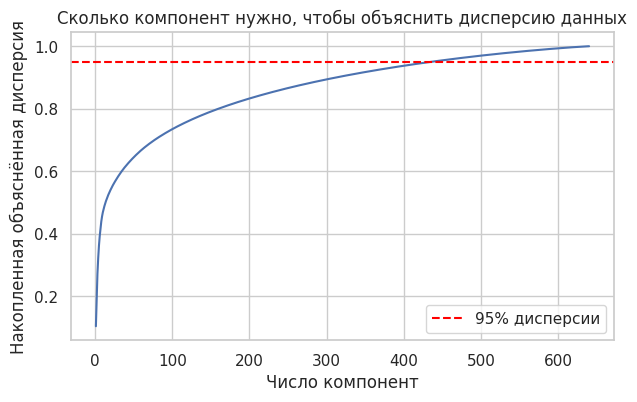

Компонент для 95% дисперсии: 435 (из 20531 исходных генов)


In [ ]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, color="#4C72B0")
ax.axhline(0.95, linestyle="--", color="red", label="95% дисперсии")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объясненная дисперсия")
ax.set_title("Сколько компонент нужно, чтобы объяснить дисперсию данных")
ax.legend()
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Компонент для 95% дисперсии: {n_components_95} (из {X_train_scaled.shape[1]} исходных генов)")


то есть получается, что подавляющее большинство генов несет дублирующую информацию

### 5.2 Визуализация первых двух компонент

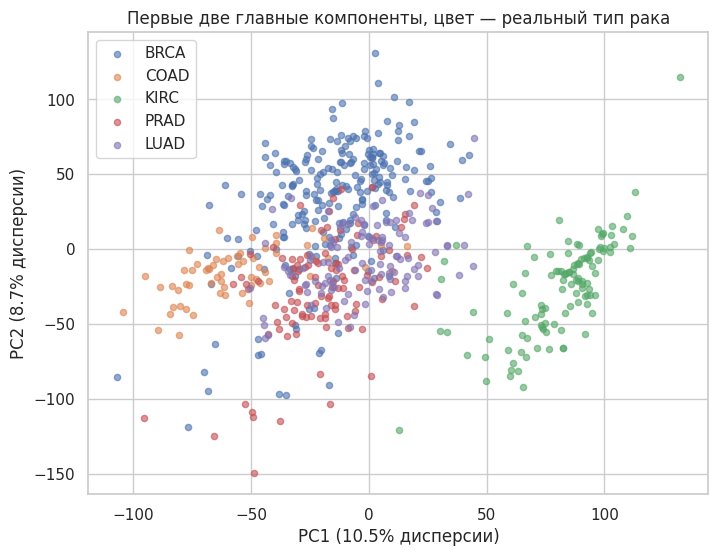

In [16]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cls in y_train.unique():
    mask = y_train == cls
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=cls, alpha=0.6, s=20)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% дисперсии)")
ax.set_title("Первые две главные компоненты, цвет — реальный тип рака")
ax.legend()
plt.show()


**PC1 и PC2 вместе объясняют только 19% дисперсии, но KIRC уже
здесь отделился почти идеально** от остальных четырех типов рака — значит,
разница между KIRC один из доминирующих
источников изменчивости в данных. PRAD и LUAD, наоборот, почти полностью
перемешаны, поэтому по первым двум компонентам их не различить. Ожидание для дальнейших разделов: SVM должен почти безошибочно отделять KIRC

### 5.3 Обучение PCA с числом компонент, покрывающим 95% дисперсии

In [18]:
pca = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Было признаков:", X_train_scaled.shape[1])
print("Стало признаков:", X_train_pca.shape[1])

Было признаков: 20531
Стало признаков: 435


### 5.4 t-SNE — альтернативная, нелинейная визуализация

PCA это линейный метод, сохраняющий глобальную структуру данных за счет
направлений максимальной дисперсии. 

**t-SNE** устроен иначе: он фокусируется только на том, чтобы
точки, близкие в исходном пространстве, остались близкими и на 2D-картинке —
из-за этого t-SNE часто визуально "растаскивает" кластеры четче, чем линейная PCA-проекция

**Важная оговорка** t-SNE — инструмент только для
визуализации

В отличие от PCA, у него нет осмысленного способа применить
уже обученное преобразование к новым точкам, а расстояния на итоговой картинке не сохраняют исходную плотность и масштаб — поэтому **кластеризовать
t-SNE координаты считается
общепринятой плохой практикой**, даже если результат выглядит убедительно.


Здесь t-SNE используется только для того, чтобы *посмотреть* на данные —
SVM и K-means по-прежнему работают на PCA-компонентах,
а не на t-SNE-координатах. Для скорости и устойчивости t-SNE запускается не
на всех 20531 исходных признаках, а поверх уже посчитанных PCA-компонент


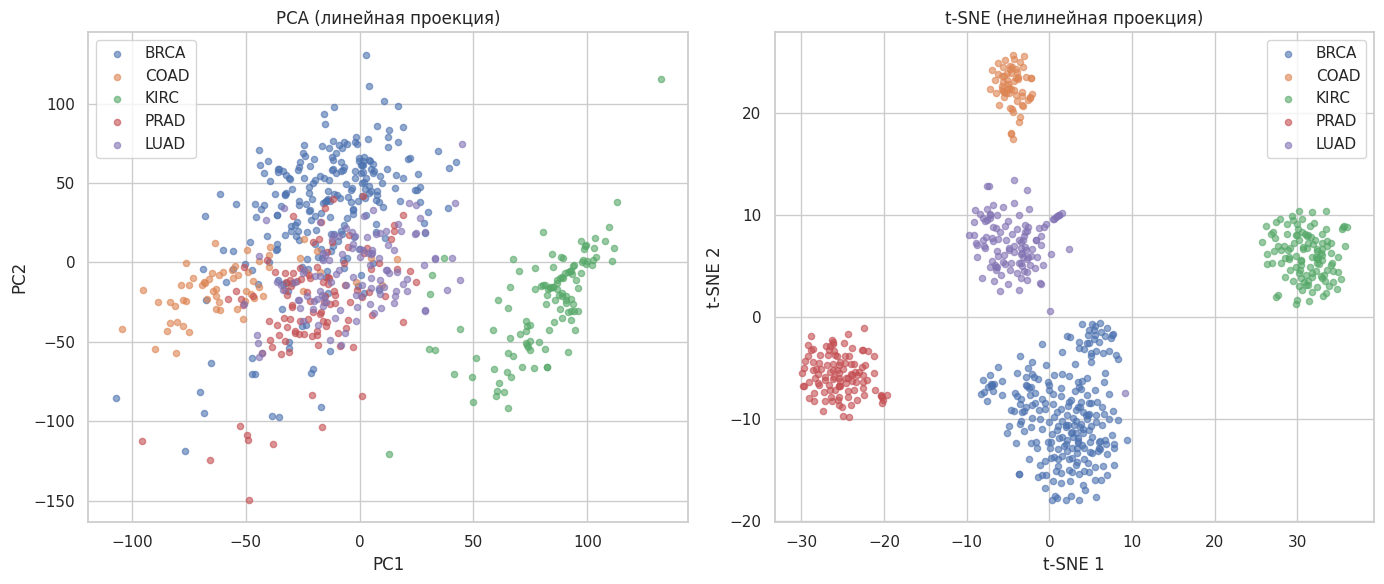

In [19]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
X_train_tsne = tsne.fit_transform(X_train_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in y_train.unique():
    mask = (y_train == cls).values
    axes[0].scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=cls, alpha=0.6, s=20)
axes[0].set_title("PCA (линейная проекция)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for cls in y_train.unique():
    mask = (y_train == cls).values
    axes[1].scatter(X_train_tsne[mask, 0], X_train_tsne[mask, 1], label=cls, alpha=0.6, s=20)
axes[1].set_title("t-SNE (нелинейная проекция)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend()

plt.tight_layout()
plt.show()


**t-SNE опровергает предположение, сделанное по PCA-графику** 

На линейной PCA (первые 2 компоненты, 19% дисперсии) PRAD и LUAD казались
неразличимыми

t-SNE развел все 5 типов рака на отдельные плотные кластеры,
включая PRAD и LUAD, то есть неразличимость на PCA-графике — это следствие
того, что 2 линейные компоненты объясняют слишком малую долю дисперсии. Ожидание по SVM/K-means стоит пересмотреть в сторону более оптимистичного: у обоих методов, работающих на 435 PCA-компонентах есть реальный шанс хорошо разделить и эту пару тоже

## 6. SVM — с PCA и без


### 6.1 SVM без PCA — на всех исходных признаках

In [20]:
start = time.time()

svm_no_pca = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_no_pca.fit(X_train_scaled, y_train)

time_no_pca = time.time() - start

pred_no_pca = svm_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, pred_no_pca)
f1_no_pca = f1_score(y_test, pred_no_pca, average="macro")

print(f"SVM без PCA — accuracy: {acc_no_pca:.4f} | macro F1: {f1_no_pca:.4f} | время обучения: {time_no_pca:.2f} сек")

SVM без PCA — accuracy: 0.9814 | macro F1: 0.9840 | время обучения: 2.67 сек


In [30]:
cv_scores_no_pca = cross_val_score(
    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_scaled, y_train, cv=5, scoring="f1_macro",
)
print("macro F1 по 5 фолдам (без PCA):", cv_scores_no_pca.round(4))
print(f"Среднее: {cv_scores_no_pca.mean():.4f} ± {cv_scores_no_pca.std():.4f}")

macro F1 по 5 фолдам (без PCA): [0.9833 1.     0.9937 0.9868 0.987 ]
Среднее: 0.9902 ± 0.0060


### 6.2 SVM после PCA

In [22]:
start = time.time()

svm_pca = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_pca.fit(X_train_pca, y_train)

time_pca = time.time() - start

pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, pred_pca)
f1_pca = f1_score(y_test, pred_pca, average="macro")

print(f"SVM после PCA — accuracy: {acc_pca:.4f} | macro F1: {f1_pca:.4f} | время обучения: {time_pca:.2f} сек")

SVM после PCA — accuracy: 1.0000 | macro F1: 1.0000 | время обучения: 0.06 сек


In [31]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_pca, y_train, cv=5, scoring="f1_macro",
)
print("macro F1 по 5 фолдам:", cv_scores.round(4))
print(f"Среднее: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

macro F1 по 5 фолдам: [0.9833 1.     0.9937 0.9868 0.9804]
Среднее: 0.9888 ± 0.0071


### 6.4 Confusion matrix лучшей модели

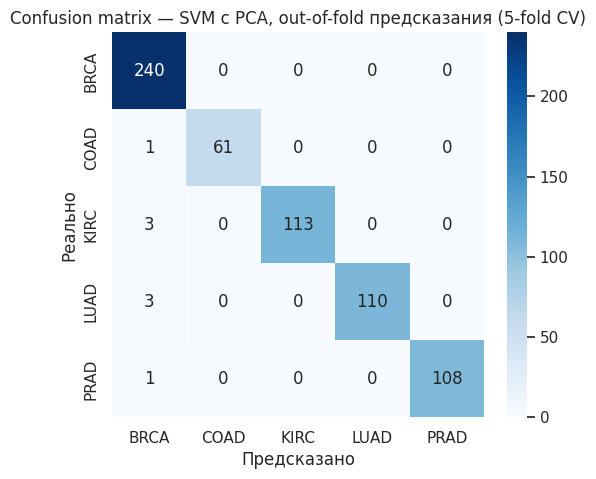

              precision    recall  f1-score   support

        BRCA       0.97      1.00      0.98       240
        COAD       1.00      0.98      0.99        62
        KIRC       1.00      0.97      0.99       116
        LUAD       1.00      0.97      0.99       113
        PRAD       1.00      0.99      1.00       109

    accuracy                           0.99       640
   macro avg       0.99      0.98      0.99       640
weighted avg       0.99      0.99      0.99       640



In [44]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(
    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_pca, y_train, cv=5,
)

cm_cv = confusion_matrix(y_train, y_pred_cv, labels=sorted(y_raw.unique()))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_cv, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=sorted(y_raw.unique()), yticklabels=sorted(y_raw.unique()))
ax.set_xlabel("Предсказано")
ax.set_ylabel("Реально")
ax.set_title("Confusion matrix — SVM с PCA, out-of-fold предсказания (5-fold CV)")
plt.show()

print(classification_report(y_train, y_pred_cv))

### 6.5 Сравнение SVM с PCA и без

In [38]:
from sklearn.model_selection import cross_validate

cv_results_no_pca = cross_validate(
    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_scaled, y_train, cv=5, scoring=["accuracy", "f1_macro"],
)
cv_results_pca = cross_validate(
    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    X_train_pca, y_train, cv=5, scoring=["accuracy", "f1_macro"],
)

svm_results = pd.DataFrame([
    {
        "model": "SVM без PCA",
        "accuracy (CV)": f"{cv_results_no_pca['test_accuracy'].mean():.4f} ± {cv_results_no_pca['test_accuracy'].std():.4f}",
        "macro_F1 (CV)": f"{cv_results_no_pca['test_f1_macro'].mean():.4f} ± {cv_results_no_pca['test_f1_macro'].std():.4f}",
        "среднее время обучения на фолд, сек": cv_results_no_pca["fit_time"].mean().round(3),
    },
    {
        "model": "SVM с PCA",
        "accuracy (CV)": f"{cv_results_pca['test_accuracy'].mean():.4f} ± {cv_results_pca['test_accuracy'].std():.4f}",
        "macro_F1 (CV)": f"{cv_results_pca['test_f1_macro'].mean():.4f} ± {cv_results_pca['test_f1_macro'].std():.4f}",
        "среднее время обучения на фолд, сек": cv_results_pca["fit_time"].mean().round(3),
    },
])
svm_results

,model,accuracy (CV),macro_F1 (CV),"среднее время обучения на фолд, сек"
0,SVM без PCA,0.9891 ± 0.0063,0.9902 ± 0.0060,1.916
1,SVM с PCA,0.9875 ± 0.0080,0.9888 ± 0.0071,0.042


**PCA почти не изменила точность, но ускорила обучение**

Честная 5-fold кросс-валидация: accuracy 0.9891±0.0063 / macro F1
0.9902±0.0060 без PCA против accuracy 0.9875±0.0080 / macro F1 0.9888±0.0071
с PCA — разница внутри одного стандартного отклонения, статистически не
значима

При этом среднее время обучения на фолд упало с 1.916 сек до
0.042 сек, то есть ускорение примерно в **45 раз**

**Итог:** 

PCA в этом проекте не улучшила и не ухудшила качество классификации
за пределами шума, но дала 45-кратный выигрыш в скорости
без потери точности. Для датасета это ожидаемый и результат: почти вся полезная для классификации информация укладывается в 435 компонент, а
оставшиеся отброшенные признаки были в избыточны или
шумны

## 7. K-means — можно ли найти типы рака вообще без меток?

**Adjusted Rand Index (ARI)** — сравнивает два разбиения на группы (найденные
кластеры vs реальные классы), учитывая, что часть совпадений могла бы
произойти случайно

ARI = 1 — полное совпадение группировок 

ARI ≈ 0 — результат не лучше случайного разбиения. 

ARI < 0 — хуже случайного

**Silhouette score** — насколько компактны и хорошо разделены сами найденные кластеры 


### 7.1 Метод локтя и silhouette score — сколько кластеров предложил бы алгоритм сам, не зная про 5 типов рака

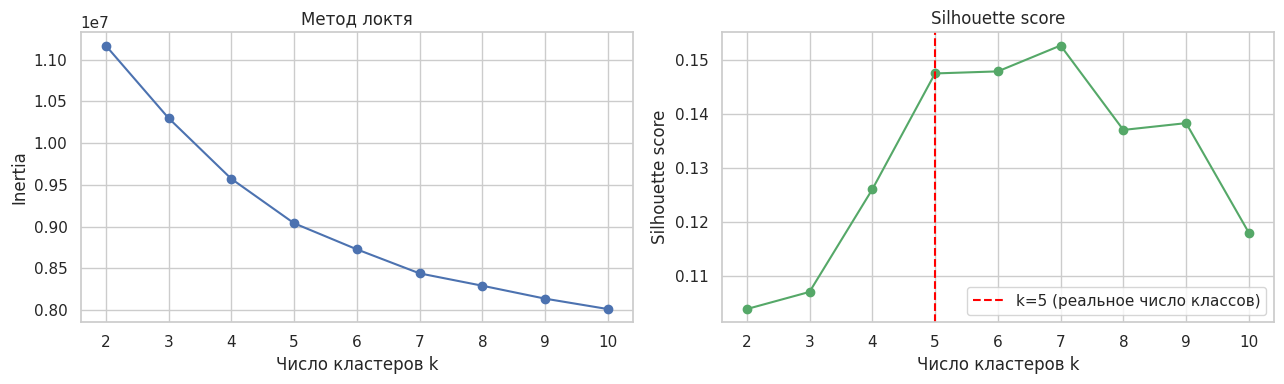

In [39]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_train_pca)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_train_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertia_values, marker="o", color="#4C72B0")
axes[0].set_xlabel("Число кластеров k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Метод локтя")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="#55A868")
axes[1].axvline(5, linestyle="--", color="red", label="k=5 (реальное число классов)")
axes[1].set_xlabel("Число кластеров k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette score")
axes[1].legend()
plt.tight_layout()
plt.show()

**Метод локтя и silhouette score не дают однозначного подтверждения k=5** 

Метод локтя показывает плавное падение без резкого
излома. Silhouette score пиковый на k=7, без выраженного максимума
именно на 5. 

Вероятной причиной можно назвать то, что эти метрики оптимизируют геометрическую компактность кластеров, а реальные типы рака, скорее всего, разного размера и формы в пространстве 435 компонент, поэтому геометрически
оптимальное число кластеров не обязано совпадать с биологической
разметкой на 5 классов

### 7.2 K-means с k=5

In [40]:
kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_train_pca)

ari = adjusted_rand_score(y_train, cluster_labels)
print(f"ARI (кластеры vs реальные типы рака): {ari:.4f}")

ARI (кластеры vs реальные типы рака): 0.8146


**ARI = 0.8146 — сильное совпадение кластеров K-means с реальными типами
рака, но не идеальное** 

### 7.3 Таблица сопряженности — какой кластер соответствует какому реальному классу

In [41]:
contingency = pd.crosstab(y_train.values, cluster_labels,
                           rownames=["Реальный класс"], colnames=["Кластер K-means"])
contingency

Кластер K-means,0,1,2,3,4
Реальный класс,,,,,
BRCA,37,0,203,0,0
COAD,4,0,0,0,58
KIRC,0,0,0,116,0
LUAD,111,0,2,0,0
PRAD,1,107,1,0,0


**Таблица сопряженности уточняет и частично опровергает предположение из
раздела с 2D PCA-графиком** 

KIRC (кластер 3) и PRAD (кластер 1) выделились
K-means почти идеально, без учителя. 
Однако основная путаница не PRAD с LUAD, как предполагалось по PCA, а полное отсутствие у LUAD собственного кластера: 111 из ~113 объектов LUAD попали в общий кластер 0 вместе с остатками BRCA и COAD

Вероятной причиной можно назвать то, что K-means ищет
сферические, геометрически компактные группы, и LUAD не
образует такой явной, обособленной группы в PCA-пространстве, в отличие от
KIRC и PRAD — при этом SVM (видящий метки в обучении) все равно способен
отличать LUAD от остальных, проводя границу не обязательно сферической
формы, что и объясняет разрыв между почти идеальным SVM и
хорошим, но не идеальным K-means

### 7.4 Визуальное сравнение — реальные классы vs найденные кластеры

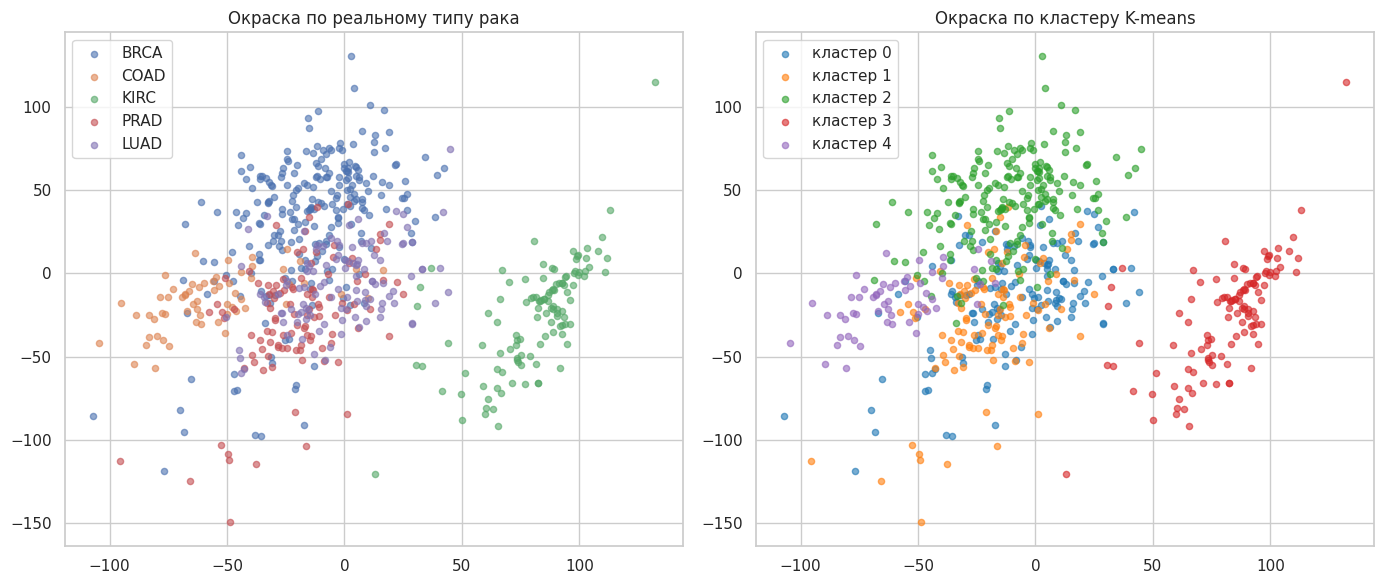

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for cls in y_train.unique():
    mask = (y_train == cls).values
    axes[0].scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=cls, alpha=0.6, s=20)
axes[0].set_title("Окраска по реальному типу рака")
axes[0].legend()

palette = sns.color_palette("tab10", n_colors=5)
for cluster_id in sorted(set(cluster_labels)):
    mask = cluster_labels == cluster_id
    axes[1].scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                     label=f"кластер {cluster_id}", color=palette[cluster_id], alpha=0.6, s=20)
axes[1].set_title("Окраска по кластеру K-means")
axes[1].legend()

plt.tight_layout()
plt.show()

**Совпадение частичное, но не полное.** 

KIRC полностью совпадает по форме и
положению на обоих графиках — K-means нашел эту группу геометрически, без
единой метки

PRAD совпадает почти полностью (кластер 3), с небольшим
захватом соседних точек

Но вот BRCA, COAD и особенно LUAD в центральном
облаке кластеризация без учителя развести не смогла 

Наиболее вероятная путаница — не PRAD/LUAD, как можно было бы
предположить по одной 2D PCA-проекции, а отсутствие у LUAD собственного
кластера вообще: он остался среди BRCA/COAD

## 8. Выводы

**PCA — сколько компонент реально нужно** 

435 компонент из 20531 исходных
объясняют 95% дисперсии

**SVM с PCA vs без** 

На одном train/test разбиении: accuracy без PCA — 0.9814, с PCA — 1.0000;
время обучения — 2.67 сек без PCA против 0.06 сек с PCA. На первый взгляд
PCA выглядела однозначно лучше и по качеству, и по скорости. Но честная
5-fold кросс-валидация показала другую картину: accuracy 0.9891±0.0063 /
macro F1 0.9902±0.0060 без PCA против accuracy 0.9875±0.0080 / macro F1
0.9888±0.0071 с PCA — диапазоны полностью перекрываются, разница в точности
статистически не значима. Единственное надежно воспроизводимое
преимущество PCA — не точность, а скорость: среднее время обучения на фолд
1.916 сек без PCA против 0.042 сек с PCA

**K-means vs реальные типы рака** 

Adjusted Rand Index = 0.8146 — не идеальное совпадение. Судя по таблице сопряженности и визуальному сравнению, кластеризация без учителя лучше всего
восстанавливает KIRC (116 из 116, идеально) и почти идеально — PRAD (107
из 109). Хуже всего — LUAD: 111 из 113 объектов не образовали свой
кластер вообще, а "растворились" в общем сборном кластере вместе с
остатками BRCA и COAD. На самом деле PRAD отделился хорошо, а LUAD просто не
сформировал собственного геометрически компактного кластера

**Ограничение** 

Устойчивость ARI к другим случайным инициализациям K-means отдельно не проверялась. Общий объем
данных (801 образец) также остается небольшим для надежных
статистических выводов о редких классах (COAD, PRAD)

**Что можно улучшить дальше** 

Feature selection на основе биологической
значимости генов; иерархическая кластеризация вместо K-means — проверить,
разделится ли смешанный кластер BRCA/COAD/LUAD на более чистые подгруппы
при менее жестком предположении о форме кластеров;
повторить ARI на нескольких разных random_state для K-means, чтобы
убедиться, что 0.8146 устойчивый результат